In [8]:
# Run this cell first in every notebook
import sys
import os
sys.path.append(os.path.abspath('../src'))

%load_ext autoreload
%autoreload 2

# Now you can import your code!
# import hardware_test

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


--------------------------------------------------
✅ Zadoff-Chu Peak found at sample index: 240000
📍 Known Pilots begin at sample index: 242753
--------------------------------------------------


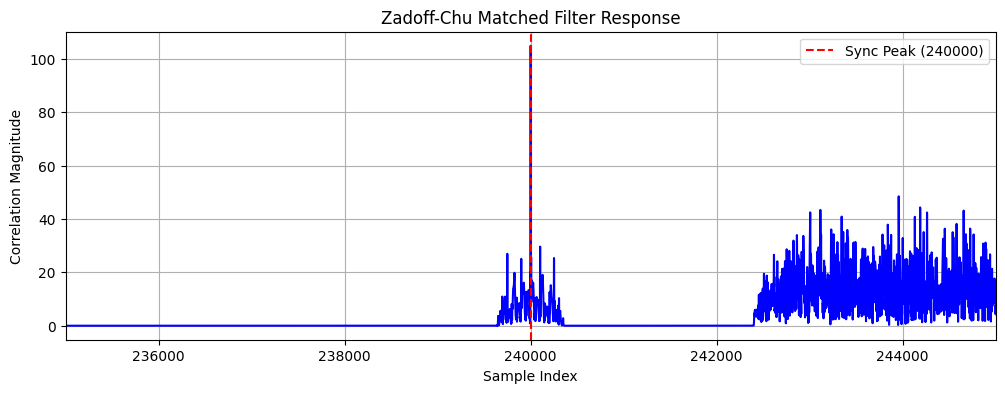

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, filtfilt, fftconvolve

# --- 1. System Parameters (Match these exactly to TX!) ---
FS = 48000
F_CARRIER = 10000
SYMBOL_RATE = 7000     # Change this if you used a different baud rate
ZC_ROOT = 7
ZC_LENGTH = 353

# --- 2. Load the Audio ---
# Swap this to 'far_recording.wav' later for your 1m test
fs, rx_audio = wavfile.read('../data/tx_single_carrier_test.wav')

# Convert to mono if it recorded in stereo
if len(rx_audio.shape) > 1:
    rx_audio = rx_audio.mean(axis=1)

# Normalize audio to prevent math overflows
rx_audio = rx_audio / np.max(np.abs(rx_audio))

# --- 3. Demodulation (I and Q Mixing) ---
t = np.arange(len(rx_audio)) / FS

# Multiply by 2 to compensate for the 50% power loss that occurs 
# when splitting a real signal into two complex arms.
# Q is negative sin() to correctly reverse the passband modulation.
i_mixed = rx_audio * 2 * np.cos(2 * np.pi * F_CARRIER * t)
q_mixed = rx_audio * -2 * np.sin(2 * np.pi * F_CARRIER * t)

# --- 4. Low Pass Filter (Removing the 2*fc artifact) ---
# When you multiply by the carrier, you get baseband data + a copy at 20 kHz.
# We use a Butterworth LPF to slice off the 20 kHz artifact.
# Cutoff frequency is set to the Symbol Rate (bandwidth of your baseband signal).
cutoff_hz = SYMBOL_RATE 
nyq = 0.5 * FS
normal_cutoff = cutoff_hz / nyq
b, a = butter(5, normal_cutoff, btype='low', analog=False)

# filtfilt applies the filter forward and backward, ensuring ZERO phase shift (crucial for QAM)
i_baseband = filtfilt(b, a, i_mixed)
q_baseband = filtfilt(b, a, q_mixed)

# Combine into our complex baseband signal!
rx_baseband = i_baseband + 1j * q_baseband

# --- 5. Zadoff-Chu Cross-Correlation (Synchronization) ---
def generate_zadoff_chu_audio(N, u):
    q = 0
    N_0 = np.arange(0, N, 1)
    N_1 = np.arange(1, N + 1, 1)
    
    if N % 2 == 1:  # Odd length
        y = np.exp(-1j * u * np.pi / N * np.multiply(N_0, (N_1 + 2 * q)))
    else:  # Even length
        y = np.exp(-1j * u * np.pi / N * (N_0**2))
        
    return y

# Generate the exact same reference sequence used at TX
reference_zc = generate_zadoff_chu_audio(ZC_LENGTH, ZC_ROOT)

# To find the sequence, we use a Matched Filter (convolution with the time-reversed conjugate).
# fftconvolve is mathematically identical to cross-correlation but runs 100x faster in Python.
# mode='valid' means the peak index corresponds exactly to the start index in the rx array.
matched_filter = reference_zc[::-1].conj()
corr = np.abs(fftconvolve(rx_baseband, matched_filter, mode='valid'))

zc_start_idx = np.argmax(corr)

# --- 6. Locating the Payload & Pilots ---
gap_samples = int(FS * 0.05) # 50 ms gap

# Calculate exactly where the known symbols begin
pilot_start_idx = zc_start_idx + ZC_LENGTH + gap_samples

print("-" * 50)
print(f"✅ Zadoff-Chu Peak found at sample index: {zc_start_idx}")
print(f"📍 Known Pilots begin at sample index: {pilot_start_idx}")
print("-" * 50)

# --- Visualization ---
# You want to see one massive spike and a completely flat noise floor. 
# If there are multiple spikes, you have heavy room echoes (multipath).
plt.figure(figsize=(12, 4))
plt.plot(corr, color='blue')
plt.title("Zadoff-Chu Matched Filter Response")
plt.xlabel("Sample Index")
plt.ylabel("Correlation Magnitude")
plt.axvline(zc_start_idx, color='red', linestyle='--', label=f"Sync Peak ({zc_start_idx})")
plt.xlim(max(0, zc_start_idx - 5000), min(len(corr), zc_start_idx + 5000)) # Zoom in on the peak
plt.legend()
plt.grid(True)
plt.show()

# --- 7. Placeholder for next phase ---
# TODO: Copy your exact pilot array from your teammate's TX code here

def map_bits_to_qam(bit_array, M=4):
    """Maps an array of bits to Square M-QAM complex symbols."""
    k = int(np.log2(M))
    if 2**k != M or k % 2 != 0:
        raise ValueError("M must be a perfect square (4, 16, 64, 256...)")

    #this is padding in case the no of bits we need to send is not a multiple of k
    pad_len = (k - len(bit_array) % k) % k 
    if pad_len > 0:
        bit_array = np.append(bit_array, np.zeros(pad_len, dtype=int))

    symbols = []
    k_half = k // 2
    norm_factor = np.sqrt((2/3) * (M - 1))

    for i in range(0, len(bit_array), k):
        chunk = bit_array[i:i+k]
        I_bits = chunk[:k_half]
        Q_bits = chunk[k_half:]
        
        I_val = int("".join(map(str, I_bits)), 2) 
        Q_val = int("".join(map(str, Q_bits)), 2)
        
        I_amp = 2 * I_val - (2**k_half - 1)
        Q_amp = 2 * Q_val - (2**k_half - 1)
        
        symbols.append(complex(I_amp, Q_amp) / norm_factor)
        
    return np.array(symbols)


pilot_bits = [0,1,1,0,0,1,1,0,0,1,1,0,0,1,1,0]  # 16 bits for 4-QAM (2 bits per symbol)
pilot_symbols = map_bits_to_qam(pilot_bits, 4)

KNOWN_PILOT_SYMBOLS = pilot_symbols

# Slicing the received signal to grab the pilots and the message
rx_pilots = rx_baseband[pilot_start_idx : pilot_start_idx + (len(KNOWN_PILOT_SYMBOLS) * 6)]



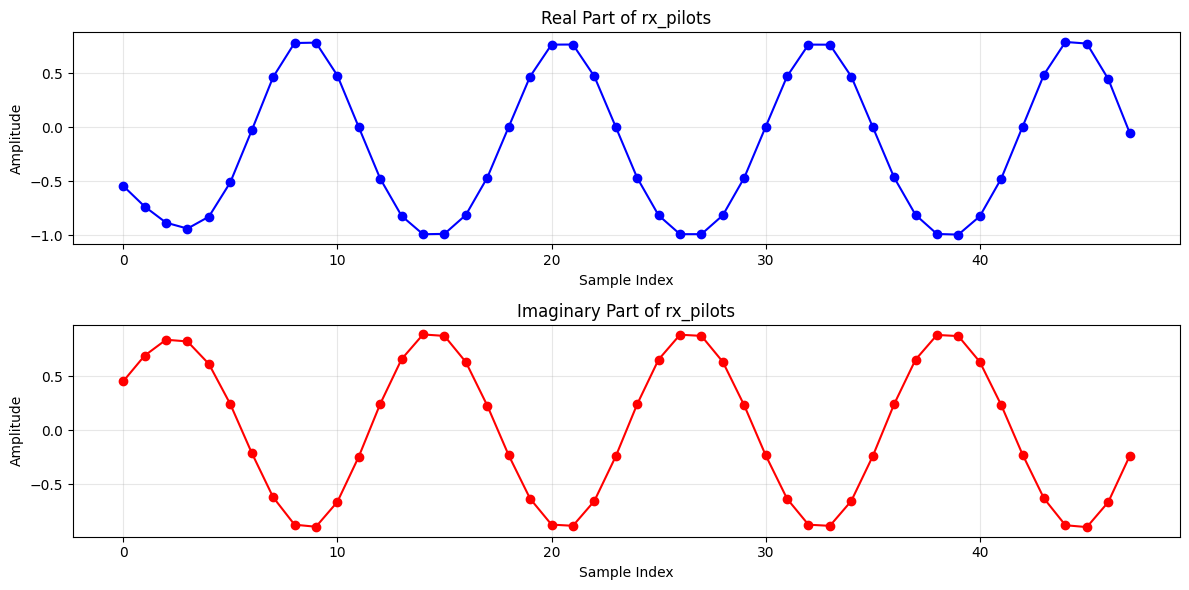

In [10]:

# Plot real and imaginary parts of rx_pilots
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Real part
axes[0].plot(np.real(rx_pilots), color='blue', marker='o', linestyle='-', linewidth=1.5)
axes[0].set_title("Real Part of rx_pilots")
axes[0].set_xlabel("Sample Index")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

# Imaginary part
axes[1].plot(np.imag(rx_pilots), color='red', marker='o', linestyle='-', linewidth=1.5)
axes[1].set_title("Imaginary Part of rx_pilots")
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
